In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

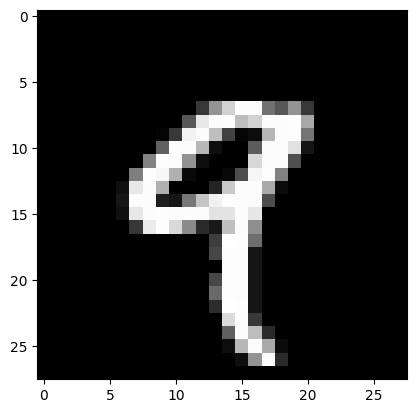

In [5]:
plt.imshow(X_train[4], cmap='gray')

In [ ]:
# Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [8]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))
X_train.shape

(60000, 784)

In [9]:
x_train_noisy = X_train + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
x_test_noisy = X_test + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

In [11]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [13]:
inputs = Input(shape=(784,))
encoder = Dense(32, activation='relu')(inputs)
decoder = Dense(784, activation='sigmoid')(encoder)

auto_encoder = Model(inputs, decoder)
auto_encoder.compile(optimizer='adam', loss='binary_crossentropy')

auto_encoder.fit(x_train_noisy, X_train, epochs=100, batch_size=256, shuffle=True, validation_data=(x_test_noisy, X_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3669 - val_loss: 0.2319
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2188 - val_loss: 0.1853
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1810 - val_loss: 0.1650
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1631 - val_loss: 0.1522
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1516 - val_loss: 0.1441
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1442 - val_loss: 0.1384
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1382 - val_loss: 0.1339
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1352 - val_loss: 0.1318
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1332 - val_loss: 0.1306
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1316 - val_loss: 0.1299
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1309 - val_loss: 0.1294
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━

In [14]:
idx = np.random.randint(X_test.shape[0])
original_image = X_test[idx]
noisy_image = x_test_noisy[idx]
denoised_image = auto_encoder.predict(np.expand_dims(noisy_image, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


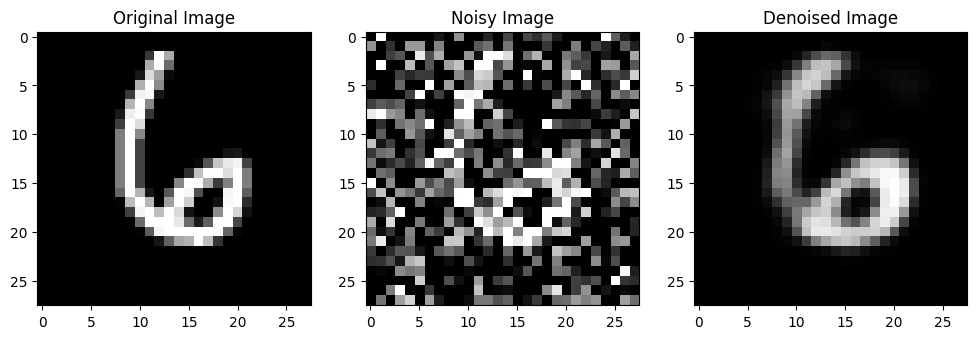

In [15]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(original_image.reshape(28, 28), cmap='gray')
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(noisy_image.reshape(28, 28), cmap='gray')
plt.title('Noisy Image')
plt.subplot(1, 3, 3)
plt.imshow(denoised_image.reshape(28, 28), cmap='gray')
plt.title('Denoised Image')
plt.show()